# Drum Transcriptor Vibro

Notebook de inferencia WAV para la tesis de transcripcion automatica de bateria con senales vibratorias/piezos, basado en el pipeline ADTOF adaptado.

Este cuadernillo esta pensado para inferir sobre WAV externos sin usar anotaciones ni TEST como parte del proceso de decision. El smoke test inicial usa un WAV del dataset `TEST/AUDIO` solo para comprobar que el flujo carga audio, predice, aplica threshold/NMS y exporta resultados.

## Que se reutiliza del notebook original `bin/drumTranscriptor.ipynb`

- Compatibilidad de `madmom` con `collections`/NumPy en Windows.
- `Model.modelFactory(...)` para reconstruir la arquitectura `Frame_RNN`.
- `Track` y `mir.preProcess(...)` para aplicar la misma extraccion de features usada por ADTOF.
- Visualizacion tipo event plot/piano-roll.

## Que se adapta para senales vibratorias

- Se abandona el esquema historico `BD, SD, TT, HH, CY+RD`.
- Se usa exclusivamente `KD, SD, T12, T14, T16` con MIDI `35, 38, 47, 45, 43`.
- Se carga el checkpoint oficial desde `fulltrack_selected_inference_config.json`.
- Se aplica threshold y NMS/refractory time desde el JSON oficial.
- Se exportan eventos como `transcription.csv` y `transcription_adtof.txt` sin depender de anotaciones.

In [1]:
# =========================
# 1) Configuracion inicial
# =========================

# Smoke test: WAV real del split TEST. Cambia esta ruta por un WAV externo de piezos cuando el flujo este validado.
input_wav_path = r"C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\pruebadefills.wav"

# Configuracion oficial de inferencia de la run actual.
inference_config_path = r"RUNS/fs2_pc/fulltrack_selected_inference_config.json"

# Carpeta de salida. Se crea automaticamente y no toca el dataset ni las corridas.
output_dir = r"OUTPUT_TRANSCRIPTIONS/smoke_test_vibro"

# Export MIDI es opcional; requiere pretty_midi.
export_midi = True

# Si el WAV real de piezos viene con una frecuencia de muestreo distinta, madmom lo remuestrea internamente
# segun la configuracion de features del modelo. No cambies esto salvo que hayas reentrenado con otra configuracion.

In [2]:
# ==========================================
# 2) Imports y compatibilidad Windows/madmom
# ==========================================

import os
import sys
import json
import warnings
import collections
import collections.abc
from pathlib import Path

# Debe definirse antes de importar TensorFlow/Keras via ADTOF.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "True")

import numpy as np

# Compatibilidad requerida por madmom en Python/NumPy recientes.
collections.MutableSequence = collections.abc.MutableSequence
collections.MutableMapping = collections.abc.MutableMapping
collections.Mapping = collections.abc.Mapping
collections.Sequence = collections.abc.Sequence
collections.Iterable = collections.abc.Iterable
for legacy_name, replacement in (("float", float), ("int", int), ("complex", complex), ("bool", bool)):
    if not hasattr(np, legacy_name):
        setattr(np, legacy_name, replacement)

import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que el repo este en sys.path tanto si el notebook se abre desde raiz como desde bin/.
NOTEBOOK_CWD = Path.cwd().resolve()
if (NOTEBOOK_CWD / "adtof").is_dir():
    project_root = NOTEBOOK_CWD
elif (NOTEBOOK_CWD.parent / "adtof").is_dir():
    project_root = NOTEBOOK_CWD.parent
else:
    raise RuntimeError("No se encontro la carpeta adtof. Abre el notebook desde la raiz del repositorio o desde bin/.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from adtof import config as adtof_config
from adtof.model.hyperparameters import models as adtof_models
from adtof.model.model import Model
from adtof.model.track import Track
from adtof.config import update as adtof_update

print("Project root:", project_root)

C:\Users\rsanc\AppData\Local\Temp\ipykernel_25404\4088452477.py:25: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, legacy_name):



Project root: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations


In [3]:
# ==============================================
# 3) Leer JSON oficial y validar esquema vibro
# ==============================================

VIBRO_CLASS_NAMES = ["KD", "SD", "T12", "T14", "T16"]
VIBRO_MIDI_LABELS = [35, 38, 47, 45, 43]


def resolve_path(path_like):
    path = Path(path_like)
    if not path.is_absolute():
        path = project_root / path
    return path.resolve()


input_wav_path = resolve_path(input_wav_path)
inference_config_path = resolve_path(inference_config_path)
output_dir = resolve_path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

with inference_config_path.open("r", encoding="utf-8") as f:
    inference_config = json.load(f)

run_dir = resolve_path(inference_config["run_dir"])
run_config_path = run_dir / "config.json"
with run_config_path.open("r", encoding="utf-8") as f:
    run_config = json.load(f)

checkpoint_path = resolve_path(inference_config["checkpoint_path"])
class_names = inference_config.get("class_names") or run_config.get("class_names")
midi_labels = inference_config.get("midi_labels") or inference_config.get("labels") or run_config.get("labels")

if class_names != VIBRO_CLASS_NAMES or midi_labels != VIBRO_MIDI_LABELS:
    raise ValueError(
        "El checkpoint/config no corresponde al esquema vibro vigente. "
        f"Esperado {VIBRO_CLASS_NAMES}/{VIBRO_MIDI_LABELS}, recibido {class_names}/{midi_labels}."
    )

threshold_mode = inference_config.get("threshold_mode", "global")
threshold_global = inference_config.get("threshold_global")
thresholds_per_class = inference_config.get("thresholds_per_class")
onset_nms_ms = float(inference_config.get("onset_nms_ms", inference_config.get("min_peak_distance_ms", 0.0)))
sample_rate = int(run_config.get("sample_rate", inference_config.get("sample_rate", 100)))

if thresholds_per_class:
    threshold_by_class = {name: float(thresholds_per_class[name]) for name in class_names}
else:
    threshold_by_class = {name: float(threshold_global) for name in class_names}

print("WAV:", input_wav_path)
print("Run dir:", run_dir)
print("Checkpoint:", checkpoint_path)
print("Classes:", dict(zip(class_names, midi_labels)))
print("Threshold mode:", threshold_mode, threshold_by_class)
print("NMS ms:", onset_nms_ms)
print("Model sample rate/fps:", sample_rate)

WAV: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\pruebadefills.wav
Run dir: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\RUNS\serious_5class_low_60ep_focal_soft_toms_v2
Checkpoint: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\RUNS\serious_5class_low_60ep_focal_soft_toms_v2\checkpoints\best_weights.weights.h5
Classes: {'KD': 35, 'SD': 38, 'T12': 47, 'T14': 45, 'T16': 43}
Threshold mode: per-class {'KD': 0.075, 'SD': 0.05, 'T12': 0.04, 'T14': 0.04, 'T16': 0.03}
NMS ms: 110.0
Model sample rate/fps: 100


In [4]:
# ========================================================
# 4) Construir hparams y cargar modelo/checkpoint oficial
# ========================================================

model_name = run_config.get("model_name", "Frame_RNN")

# Partimos de los hiperparametros oficiales de ADTOF y reemplazamos solo lo que la corrida vibro fijo.
hparams = adtof_update(
    {
        "labels": midi_labels,
        "sampleRate": sample_rate,
        "trainingSequence": int(run_config.get("training_sequence", 64)),
        "context": int(run_config.get("context", 9)),
        "batchSize": int(run_config.get("batch_size", 1)),
        "samePadding": bool(run_config.get("same_padding", True)),
        "n_channels": 1,
        "sampleWeight": run_config.get("class_weights", [1.0] * len(class_names)),
    },
    adtof_models[model_name].copy(),
)

# Reforzar parametros criticos de la corrida despues del update.
hparams["labels"] = midi_labels
hparams["sampleRate"] = sample_rate
hparams["trainingSequence"] = int(run_config.get("training_sequence", hparams.get("trainingSequence", 64)))
hparams["context"] = int(run_config.get("context", hparams.get("context", 9)))
hparams["batchSize"] = int(run_config.get("batch_size", hparams.get("batchSize", 1)))
hparams["samePadding"] = bool(run_config.get("same_padding", hparams.get("samePadding", True)))
hparams["n_channels"] = 1

model, _ = Model.modelFactory(
    modelName=model_name,
    scenario="vibro_external_wav",
    fold=0,
    **hparams,
)

# Validacion defensiva de metadatos del checkpoint.
metadata_path = checkpoint_path.parent / "checkpoint_metadata.json"
if metadata_path.exists():
    with metadata_path.open("r", encoding="utf-8") as f:
        checkpoint_metadata = json.load(f)
    if checkpoint_metadata.get("class_names") != class_names or checkpoint_metadata.get("labels") != midi_labels:
        raise ValueError(f"Metadata de checkpoint incompatible: {checkpoint_metadata}")
else:
    warnings.warn("No se encontro checkpoint_metadata.json junto al checkpoint; se continua usando el JSON oficial.")

model.model.load_weights(str(checkpoint_path))
print("Modelo cargado:", model_name)
print("Weights cargados:", checkpoint_path)
print("Input hparams clave:", {k: hparams[k] for k in ["sampleRate", "trainingSequence", "context", "samePadding", "n_channels", "labels"]})



Modelo cargado: Frame_RNN
Weights cargados: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\RUNS\serious_5class_low_60ep_focal_soft_toms_v2\checkpoints\best_weights.weights.h5
Input hparams clave: {'sampleRate': 100, 'trainingSequence': 64, 'context': 9, 'samePadding': False, 'n_channels': 1, 'labels': [35, 38, 47, 45, 43]}


In [5]:
# =============================================
# 5) Cargar WAV y extraer features ADTOF/madmom
# =============================================

if not input_wav_path.is_file():
    raise FileNotFoundError(input_wav_path)

# Track usa mir.preProcess internamente. No se entrega annotationPath, por lo tanto no se usan anotaciones.
track = Track(
    str(r"C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\pruebadefills.wav"),
    annotationPath=None,
    sampleRate=sample_rate,
    labels=midi_labels,
    context=hparams["context"],
    samePadding=hparams["samePadding"],
    n_channels=hparams["n_channels"],
)

features = np.asarray(track.x)
duration_sec = len(features) / sample_rate
print("Feature tensor shape (frames, bands, channels):", features.shape)
print(f"Duracion aproximada por features: {duration_sec:.2f} s")

Feature tensor shape (frames, bands, channels): (708, 84, 1)
Duracion aproximada por features: 7.08 s


In [6]:
# ============================
# 6) Prediccion de activaciones
# ============================

activations = model.predict(track, **hparams)
activations = np.asarray(activations)

if activations.ndim != 2 or activations.shape[1] != len(class_names):
    raise ValueError(f"Forma inesperada de activaciones: {activations.shape}")

activation_times = np.arange(len(activations)) / sample_rate
print("Activations shape (frames, classes):", activations.shape)
print("Activation time range:", float(activation_times[0]), "->", float(activation_times[-1]) if len(activation_times) else 0.0)

Activations shape (frames, classes): (700, 5)
Activation time range: 0.0 -> 6.99


In [7]:
# ============================================================
# 7) Threshold + NMS/refractory time por clase desde el JSON
# ============================================================


def local_peak_candidates(values, threshold):
    values = np.asarray(values)
    if len(values) == 0:
        return np.array([], dtype=int)
    above = values >= threshold
    prev_values = np.r_[-np.inf, values[:-1]]
    next_values = np.r_[values[1:], -np.inf]
    # Pico local; si hay plateau, toma el primer frame que supera y no cae frente al anterior.
    local_max = above & (values >= prev_values) & (values > next_values)
    crossings = above & np.r_[True, ~above[:-1]]
    return np.flatnonzero(local_max | crossings)


def apply_refractory_nms(candidate_frames, confidences, nms_frames):
    if len(candidate_frames) == 0:
        return []
    order = sorted(candidate_frames, key=lambda idx: float(confidences[idx]), reverse=True)
    kept = []
    for frame_idx in order:
        if all(abs(int(frame_idx) - int(existing)) > nms_frames for existing in kept):
            kept.append(int(frame_idx))
    return sorted(kept)


nms_frames = int(round((onset_nms_ms / 1000.0) * sample_rate))
events = []

for class_idx, (class_name, midi_pitch) in enumerate(zip(class_names, midi_labels)):
    threshold = float(threshold_by_class[class_name])
    values = activations[:, class_idx]
    candidates = local_peak_candidates(values, threshold)
    kept_frames = apply_refractory_nms(candidates, values, nms_frames)
    for frame_idx in kept_frames:
        events.append(
            {
                "timestamp_sec": frame_idx / sample_rate,
                "class_name": class_name,
                "midi_pitch": int(midi_pitch),
                "confidence": float(values[frame_idx]),
                "threshold": threshold,
                "nms_ms": onset_nms_ms,
                "frame": int(frame_idx),
            }
        )

events_df = pd.DataFrame(events).sort_values(["timestamp_sec", "midi_pitch"]).reset_index(drop=True)
public_columns = ["timestamp_sec", "class_name", "midi_pitch", "confidence", "threshold", "nms_ms"]
print("Eventos detectados:", len(events_df))
display(events_df[public_columns].head(20))

Eventos detectados: 22


,timestamp_sec,class_name,midi_pitch,confidence,threshold,nms_ms
0,0.00,T12,47,0.052173,0.040,110.0
1,1.35,KD,35,0.088426,0.075,110.0
2,2.06,KD,35,0.099817,0.075,110.0
3,2.89,T12,47,0.058459,0.040,110.0
4,3.03,T12,47,0.058517,0.040,110.0
5,3.45,KD,35,0.085243,0.075,110.0
6,4.10,KD,35,0.140454,0.075,110.0
7,4.75,T14,45,0.042591,0.040,110.0
8,4.81,KD,35,0.140346,0.075,110.0
9,4.81,SD,38,0.341075,0.050,110.0


In [8]:
# =============================
# 8) Exportar CSV, ADTOF TXT y MIDI opcional
# =============================

csv_path = output_dir / "transcription.csv"
adtof_txt_path = output_dir / "transcription_adtof.txt"
mid_path = output_dir / "transcription.mid"

# CSV legible para analisis posterior.
events_df[public_columns].to_csv(csv_path, index=False, encoding="utf-8")

# Formato ADTOF/MIREX simple: tiempo\tMIDI_pitch.
with adtof_txt_path.open("w", encoding="utf-8", newline="") as f:
    for _, row in events_df.iterrows():
        f.write(f"{row['timestamp_sec']:.6f}\t{int(row['midi_pitch'])}\n")

midi_exported = False
if export_midi:
    try:
        import pretty_midi
        midi = pretty_midi.PrettyMIDI()
        instrument = pretty_midi.Instrument(program=0, is_drum=True, name="vibro_drums")
        for _, row in events_df.iterrows():
            start = float(row["timestamp_sec"])
            velocity = int(np.clip(round(float(row["confidence"]) * 127), 1, 127))
            note = pretty_midi.Note(
                velocity=velocity,
                pitch=int(row["midi_pitch"]),
                start=start,
                end=start + 0.05,
            )
            instrument.notes.append(note)
        midi.instruments.append(instrument)
        midi.write(str(mid_path))
        midi_exported = True
    except Exception as exc:
        warnings.warn(f"No se pudo exportar MIDI opcional: {exc}")

print("CSV:", csv_path)
print("ADTOF TXT:", adtof_txt_path)
print("MIDI:", mid_path if midi_exported else "no exportado")

CSV: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\OUTPUT_TRANSCRIPTIONS\smoke_test_vibro\transcription.csv
ADTOF TXT: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\OUTPUT_TRANSCRIPTIONS\smoke_test_vibro\transcription_adtof.txt
MIDI: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\OUTPUT_TRANSCRIPTIONS\smoke_test_vibro\transcription.mid


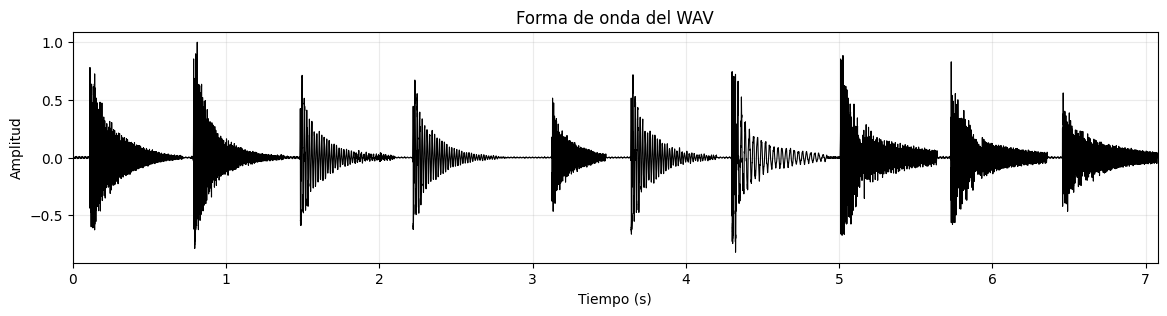

In [9]:
# =========================
# 9) Visualizar forma de onda
# =========================

try:
    import librosa
    waveform, waveform_sr = librosa.load(str(input_wav_path), sr=None, mono=True)
except Exception:
    from scipy.io import wavfile
    waveform_sr, waveform = wavfile.read(str(input_wav_path))
    waveform = np.asarray(waveform, dtype=float)
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=1)
    peak = np.max(np.abs(waveform)) or 1.0
    waveform = waveform / peak

wave_times = np.arange(len(waveform)) / waveform_sr
plt.figure(figsize=(14, 3))
plt.plot(wave_times, waveform, linewidth=0.8, color="black")
plt.title("Forma de onda del WAV")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, wave_times[-1] if len(wave_times) else 0)
plt.grid(alpha=0.25)
plt.show()

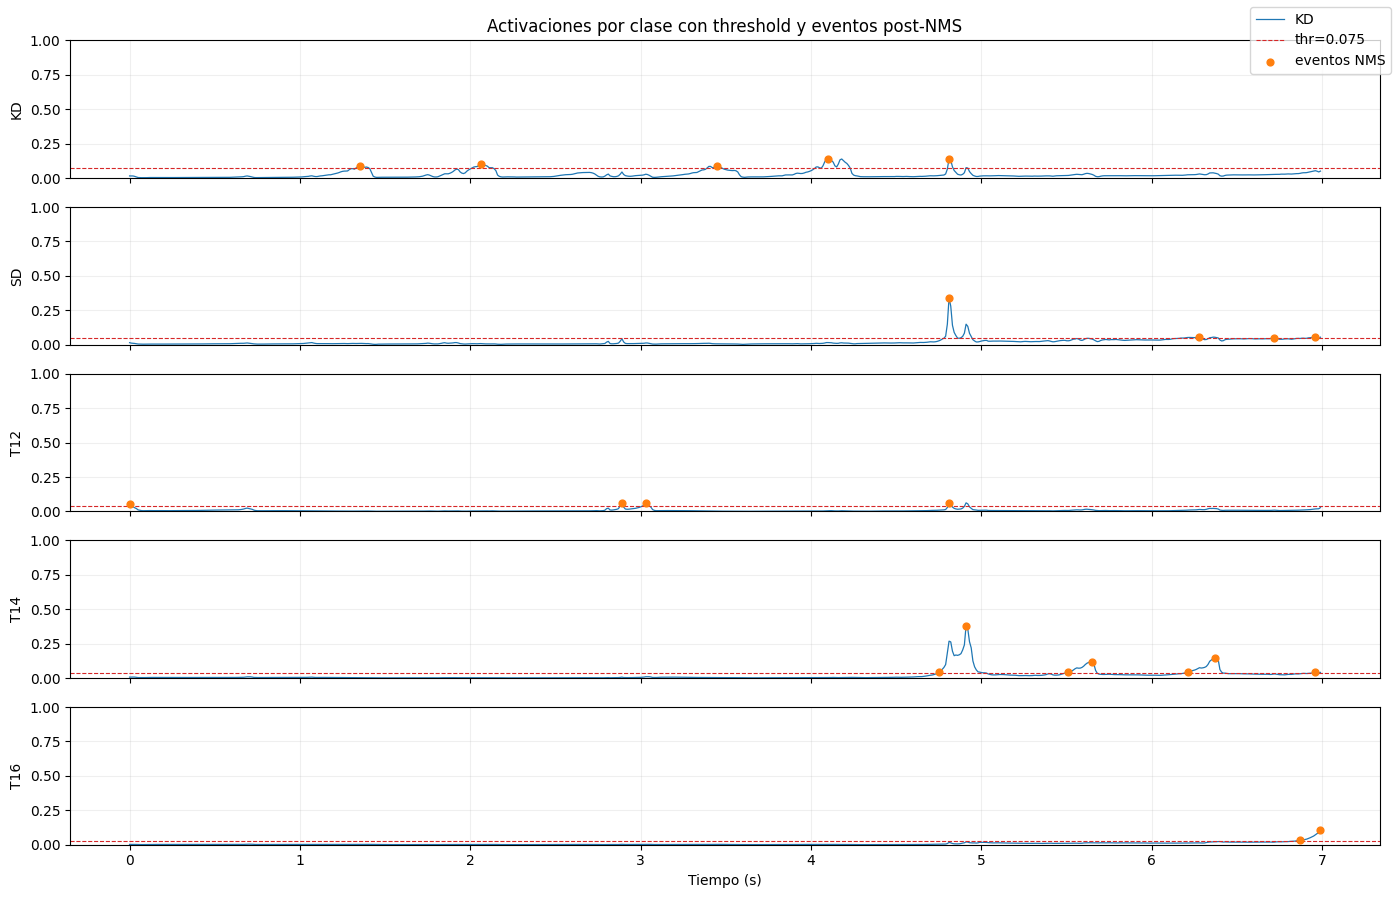

In [10]:
# ======================================================
# 10) Visualizar activaciones antes/despues de threshold
# ======================================================

fig, axes = plt.subplots(len(class_names), 1, figsize=(14, 9), sharex=True)
for class_idx, (ax, class_name) in enumerate(zip(axes, class_names)):
    values = activations[:, class_idx]
    threshold = threshold_by_class[class_name]
    ax.plot(activation_times, values, linewidth=0.9, label=class_name)
    ax.axhline(threshold, linestyle="--", linewidth=0.8, color="tab:red", label=f"thr={threshold:g}")
    class_events = events_df[events_df["class_name"] == class_name]
    if len(class_events):
        ax.scatter(class_events["timestamp_sec"], class_events["confidence"], s=24, color="tab:orange", zorder=3, label="eventos NMS")
    ax.set_ylabel(class_name)
    ax.set_ylim(0, max(1.0, float(values.max()) * 1.05))
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Tiempo (s)")
axes[0].set_title("Activaciones por clase con threshold y eventos post-NMS")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

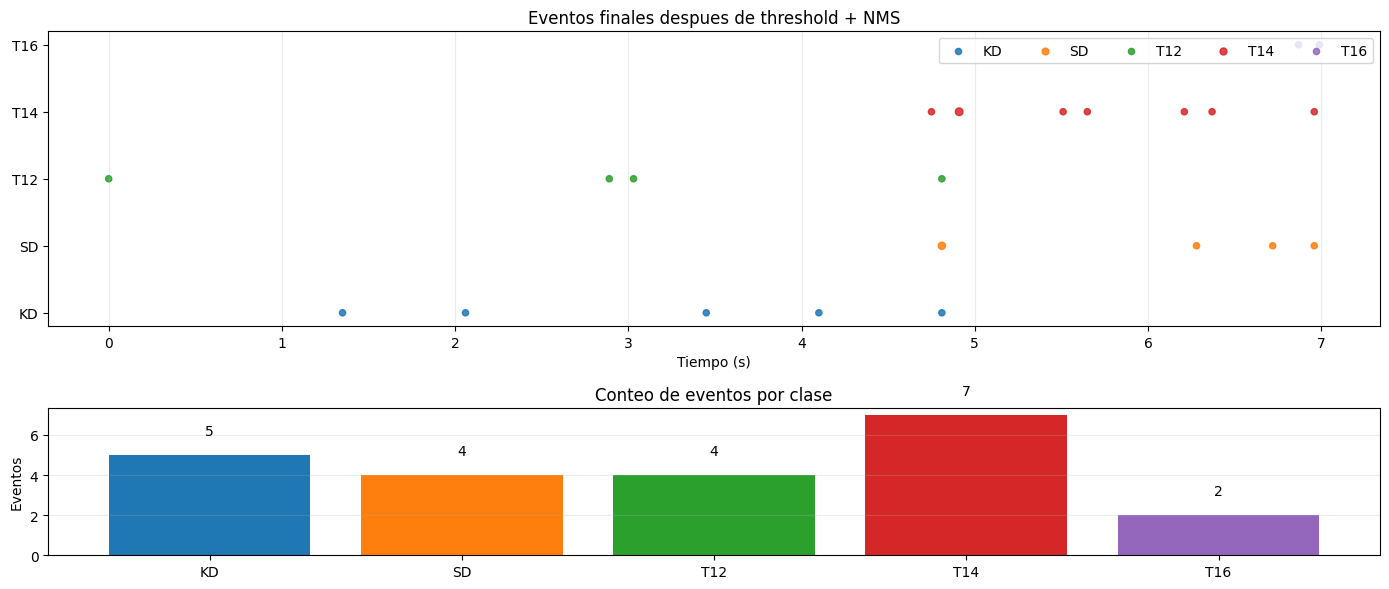

In [11]:
# ================================================
# 11) Piano-roll/event plot y conteo por clase
# ================================================

class_to_y = {name: idx for idx, name in enumerate(class_names)}
colors = dict(zip(class_names, plt.cm.tab10(np.arange(len(class_names)))))

fig, (ax_events, ax_counts) = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [2, 1]})

for class_name in class_names:
    class_events = events_df[events_df["class_name"] == class_name]
    ax_events.scatter(
        class_events["timestamp_sec"],
        [class_to_y[class_name]] * len(class_events),
        s=np.clip(class_events["confidence"] * 80, 20, 90) if len(class_events) else 20,
        color=colors[class_name],
        label=class_name,
        alpha=0.85,
    )
ax_events.set_yticks(range(len(class_names)))
ax_events.set_yticklabels(class_names)
ax_events.set_xlabel("Tiempo (s)")
ax_events.set_title("Eventos finales despues de threshold + NMS")
ax_events.grid(axis="x", alpha=0.25)
ax_events.legend(ncol=len(class_names), loc="upper right")

counts = events_df["class_name"].value_counts().reindex(class_names, fill_value=0)
ax_counts.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax_counts.set_title("Conteo de eventos por clase")
ax_counts.set_ylabel("Eventos")
ax_counts.grid(axis="y", alpha=0.25)
for i, value in enumerate(counts.values):
    ax_counts.text(i, value + max(1, counts.max() * 0.02), str(int(value)), ha="center")

plt.tight_layout()
plt.show()

In [12]:
# =======================
# 12) Resumen final
# =======================

counts = events_df["class_name"].value_counts().reindex(class_names, fill_value=0)

print("Resumen de inferencia vibro")
print("- WAV usado:", input_wav_path)
print("- Run dir:", run_dir)
print("- Checkpoint usado:", checkpoint_path)
print("- Threshold mode:", threshold_mode)
print("- Thresholds:", threshold_by_class)
print("- NMS ms:", onset_nms_ms)
print("- Eventos por clase:")
for class_name, count in counts.items():
    print(f"  {class_name}: {int(count)}")
print("- Archivos exportados:")
print("  CSV:", csv_path)
print("  ADTOF TXT:", adtof_txt_path)
if midi_exported:
    print("  MIDI:", mid_path)
print("\nNota: esta inferencia no uso anotaciones. El split TEST solo se uso como fuente de WAV para smoke test.")

Resumen de inferencia vibro
- WAV usado: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\pruebadefills.wav
- Run dir: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\RUNS\serious_5class_low_60ep_focal_soft_toms_v2
- Checkpoint usado: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\RUNS\serious_5class_low_60ep_focal_soft_toms_v2\checkpoints\best_weights.weights.h5
- Threshold mode: per-class
- Thresholds: {'KD': 0.075, 'SD': 0.05, 'T12': 0.04, 'T14': 0.04, 'T16': 0.03}
- NMS ms: 110.0
- Eventos por clase:
  KD: 5
  SD: 4
  T12: 4
  T14: 7
  T16: 2
- Archivos exportados:
  CSV: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations\OUTPUT_TRANSCRIPTIONS\smoke_test_vibro\transcription.csv
  ADTOF TXT: C:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE